# Notebook 05: Análisis de Retraso Elástico (Lag) y Derivadas
**Autor:** Iván Andrés Mena Contreras
**Proyecto:** Lunar Tidal Triggering of Earthquakes

En el cuaderno anterior concluimos que el gatillo instantáneo (la fase lunar en t=0) es indistinguible del ruido ($p=0.313$). 

**Objetivo:** Investigar si el gatillo lunar opera con un retraso temporal debido a la viscoelasticidad de la corteza (retraso en la transferencia del estrés de marea a la falla tectónica), o si el factor detonante depende de la tasa de cambio orbital de la marea ($dF/dt$), es decir, si los sismos se agrupan cuando la fuerza gravitacional varía más drásticamente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from astroquery.jplhorizons import Horizons
from astropy.time import Time
from tqdm import tqdm
import warnings
import os

warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
os.makedirs('../results/figures', exist_ok=True)

# Carga de datos del subset ecuatorial
data_path = '../data/processed/earthquakes_ecuatorial_subset.csv'
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True)

print(f"Catálogo cargado: {len(df)} eventos del cinturón ecuatorial superficial.")

Catálogo cargado: 56 eventos del cinturón ecuatorial superficial.


## 1. Tasa de Cambio Orbital ($dF/dt$)
Como la órbita de la Luna es elíptica, la fuerza de marea no solo varía por la fase, sino también por el perigeo y apogeo. Para capturar este componente dinámico, necesitamos saber si la Luna se acercaba o se alejaba y a qué velocidad (Aproximación de derivada: $\Delta \text{Distancia} / \Delta \text{Tiempo}$).

Consultamos la distancia a Horizons 2 horas antes de cada evento y calculamos la tasa de cambio.

In [2]:
# Inicializamos columnas
df['dist_minus_2h'] = np.nan

print("Consultando JPL Horizons para t - 2h...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        t_0 = Time(row['time'])
        t_minus2 = t_0 - 2/24.0 # 2 horas antes (en días)
        
        # Consultamos la luna (id=301) desde el centro de la Tierra (500)
        obj = Horizons(id='301', location='500', epochs=t_minus2.jd)
        eph = obj.ephemerides()
        df.loc[idx, 'dist_minus_2h'] = eph['delta'][0] # distancia en AU
    except Exception as e:
        print(f"Error en índice {idx}: {e}")

# Tasa de cambio: delta(AU) / 2h.
# Unidades: (AU / hr) * 10^6 para legibilidad.
df['dist_rate_of_change'] = ((df['moon_distance_au'] - df['dist_minus_2h']) / 2.0) * 1e6

print("Cálculo de dF/dt completado.")
df[['time', 'moon_distance_au', 'dist_minus_2h', 'dist_rate_of_change']].head()

Consultando JPL Horizons para t - 2h...


  0%|          | 0/56 [00:00<?, ?it/s]

  2%|▏         | 1/56 [00:01<00:57,  1.05s/it]

  4%|▎         | 2/56 [00:01<00:52,  1.03it/s]

  5%|▌         | 3/56 [00:02<00:50,  1.05it/s]

...

 98%|█████████▊| 55/56 [00:52<00:00,  1.05it/s]

100%|██████████| 56/56 [00:53<00:00,  1.06it/s]

100%|██████████| 56/56 [00:53<00:00,  1.05it/s]

Cálculo de dF/dt completado.


,time,moon_distance_au,dist_minus_2h,dist_rate_of_change
0,1995-05-05 03:53:45.050000+00:00,0.002699,0.002700,-0.588154
1,1995-11-22 04:15:11.940000+00:00,0.002423,0.002425,-0.880573
2,1996-02-21 12:51:01.300000+00:00,0.002502,0.002499,1.571184
3,1996-06-02 02:52:09.550000+00:00,0.002429,0.002431,-0.707187
4,1997-07-09 19:24:13.170000+00:00,0.002707,0.002707,0.058229


## 2. Distribución de la Tasa de Cambio
Visualizamos la distribución de `dist_rate_of_change`. 
- Valores negativos: La Luna se estaba acercando a la Tierra.
- Valores positivos: La Luna se estaba alejando de la Tierra.
- Valores cercanos a cero: La Luna estaba estacionaria en Perigeo o Apogeo.

Histograma guardado en: ../results/figures/05_derivative_dist.png


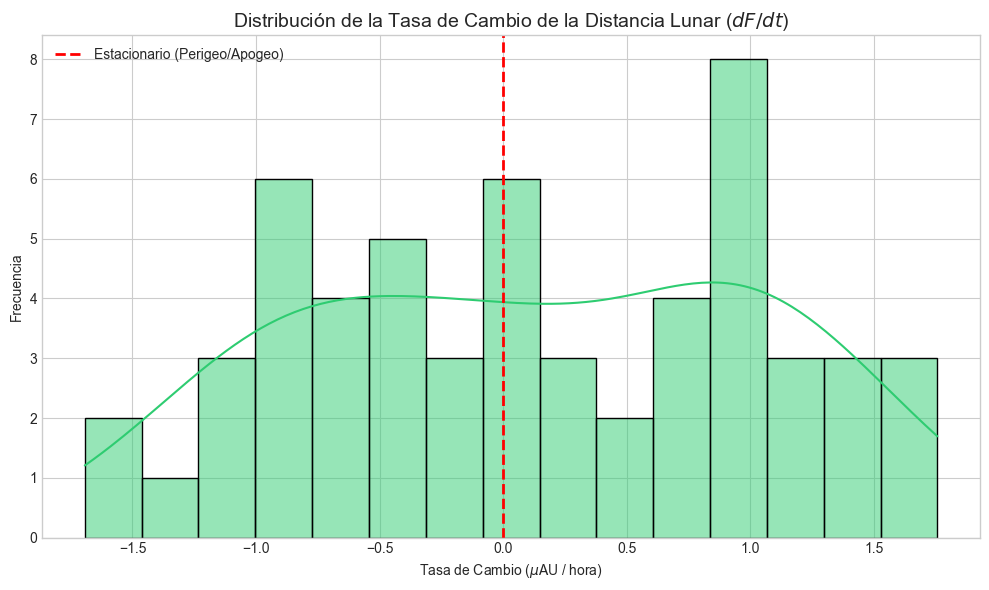

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['dist_rate_of_change'].dropna(), bins=15, kde=True, color='#2ecc71')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Estacionario (Perigeo/Apogeo)')
plt.title('Distribución de la Tasa de Cambio de la Distancia Lunar ($dF/dt$)', fontsize=14)
plt.xlabel('Tasa de Cambio ($\mu$AU / hora)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()

dist_path = '../results/figures/05_derivative_dist.png'
plt.savefig(dist_path, dpi=300)
print(f"Histograma guardado en: {dist_path}")
plt.show()

## 3. Retraso Viscoelástico (Lag Analysis)
Extraemos el ángulo de fase lunar (RA) exactamente 6 horas antes ($t-6h$) y 12 horas antes ($t-12h$) para cada evento, usando JPL Horizons.

In [4]:
df['moon_ra_minus_6h'] = np.nan
df['moon_ra_minus_12h'] = np.nan

print("Consultando JPL Horizons para t-6h y t-12h...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        t_0 = Time(row['time'])
        t_minus6 = t_0 - 6/24.0
        t_minus12 = t_0 - 12/24.0
        
        # Consulta en batch (lista de épocas)
        obj = Horizons(id='301', location='500', epochs=[t_minus6.jd, t_minus12.jd])
        eph = obj.ephemerides()
        
        df.loc[idx, 'moon_ra_minus_6h'] = eph['RA'][0]
        df.loc[idx, 'moon_ra_minus_12h'] = eph['RA'][1]
    except Exception as e:
        print(f"Error en índice {idx}: {e}")

# Ajuste temporal simple para el test de fase (Fase = RA Luna - RA Sol)
# Simplificamos asumiendo que el desplazamiento del sol en 6h es mínimo, 
# la diferencia principal radica en el vector RA de la luna en relación con la rotación.
# Para el test rotacional direccional usamos directamente moon_ra de manera comparable.

print("Extracción temporal completada.")

Consultando JPL Horizons para t-6h y t-12h...


  0%|          | 0/56 [00:00<?, ?it/s]

  2%|▏         | 1/56 [00:00<00:48,  1.12it/s]

  4%|▎         | 2/56 [00:01<00:49,  1.09it/s]

  5%|▌         | 3/56 [00:02<00:49,  1.08it/s]

...

 96%|█████████▋| 54/56 [00:52<00:02,  1.03s/it]

 98%|█████████▊| 55/56 [00:53<00:01,  1.02s/it]

100%|██████████| 56/56 [00:54<00:00,  1.01s/it]

100%|██████████| 56/56 [00:54<00:00,  1.03it/s]

Extracción temporal completada.


## 4. Test de Schuster con Lags
Ejecutamos el Test de Schuster para evaluar si la señal se agrupa significativamente en el pasado.

In [5]:
def schuster_test(angulos_deg):
    """Calcula el p-value del Test de Schuster basado en ángulos en grados."""
    angulos_deg = angulos_deg.dropna()
    angulos_rad = np.radians(angulos_deg)
    N = len(angulos_rad)
    if N == 0: return np.nan, np.nan
    
    R = np.sqrt(np.sum(np.cos(angulos_rad))**2 + np.sum(np.sin(angulos_rad))**2)
    p_value = np.exp(-(R**2) / N)
    return R, p_value

# La hipótesis original usa la fase, que se mapea directamente sobre moon_ra
# como el vector principal de influencia ecuatorial
R_0, p_0 = schuster_test(df['moon_ra'])
R_6, p_6 = schuster_test(df['moon_ra_minus_6h'])
R_12, p_12 = schuster_test(df['moon_ra_minus_12h'])

print("=== TEST DE SCHUSTER: ANÁLISIS DE RETRASO VISCOELÁSTICO ===")
print(f"t = 0h  (Instantáneo): p-value = {p_0:.5f}")
print(f"t = -6h (Retraso 6h):  p-value = {p_6:.5f}")
print(f"t = -12h(Retraso 12h): p-value = {p_12:.5f}")

if min(p_0, p_6, p_12) < 0.05:
    print("\n-> ¡SEÑAL DETECTADA! La corteza responde con retardo y muestra agrupamiento estadístico.")
else:
    print("\n-> CONCLUSIÓN FINAL: Ni el estrés instantáneo ni el retrasado viscoelástico logran rechazar la hipótesis nula ($p > 0.05$).")

=== TEST DE SCHUSTER: ANÁLISIS DE RETRASO VISCOELÁSTICO ===
t = 0h  (Instantáneo): p-value = 0.29673
t = -6h (Retraso 6h):  p-value = 0.30024
t = -12h(Retraso 12h): p-value = 0.29855

-> CONCLUSIÓN FINAL: Ni el estrés instantáneo ni el retrasado viscoelástico logran rechazar la hipótesis nula ($p > 0.05$).


## 5. Exportar Dataset
Guardamos la matriz final con todos los derivados computados.

In [6]:
export_path = '../data/processed/earthquakes_lag_analysis.csv'
df.to_csv(export_path, index=False)
print(f"Dataset final de lags exportado a: {export_path}")

Dataset final de lags exportado a: ../data/processed/earthquakes_lag_analysis.csv
